# Importing of Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [2]:
df = pd.read_csv(r".\Datasets\adult.data", header = None, delimiter = ' *, *')
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Data Cleaning

In [3]:
df.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'martial-status', 'occupation', 'relationship',
              'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df

,age,workclass,fnlwgt,education,education-num,martial-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
martial-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [5]:
for i in ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']: df[i] = df[i].astype(int)
df.dtypes

age                int32
workclass         object
fnlwgt             int32
education         object
education-num      int32
martial-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int32
capital-loss       int32
hours-per-week     int32
native-country    object
income            object
dtype: object

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
martial-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [7]:
for i in df.columns: print(i,':\n',df[i].unique())

age :
 [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
workclass :
 ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
fnlwgt :
 [ 77516  83311 215646 ...  34066  84661 257302]
education :
 ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
education-num :
 [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
martial-status :
 ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation :
 ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-suppo

In [8]:
for i in ['workclass', 'occupation', 'native-country']: print(df[i][df[i] == '?'].value_counts())

workclass
?    1836
Name: count, dtype: int64
occupation
?    1843
Name: count, dtype: int64
native-country
?    583
Name: count, dtype: int64


In [9]:
for i in ['workclass', 'occupation', 'native-country']: print(i, ':', df[i].mode())

workclass : 0    Private
Name: workclass, dtype: object
occupation : 0    Prof-specialty
Name: occupation, dtype: object
native-country : 0    United-States
Name: native-country, dtype: object


In [10]:
for i in ['workclass', 'occupation', 'native-country']: df[i].replace(['?'], df[i].mode(), inplace = True)

In [11]:
for i in ['workclass', 'occupation', 'native-country']: print(df[i][df[i] == '?'].value_counts())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [12]:
for i in ['workclass', 'occupation', 'native-country']: print(i,':\n',df[i].unique())

workclass :
 ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
occupation :
 ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
native-country :
 ['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Canada' 'Germany' 'Iran' 'Philippines' 'Italy'
 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador' 'Laos' 'Taiwan'
 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador' 'France'
 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']


In [13]:
df = df.drop(['fnlwgt'], axis = 1)
df.columns

Index(['age', 'workclass', 'education', 'education-num', 'martial-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'income'],
      dtype='object')

# Data Analysis

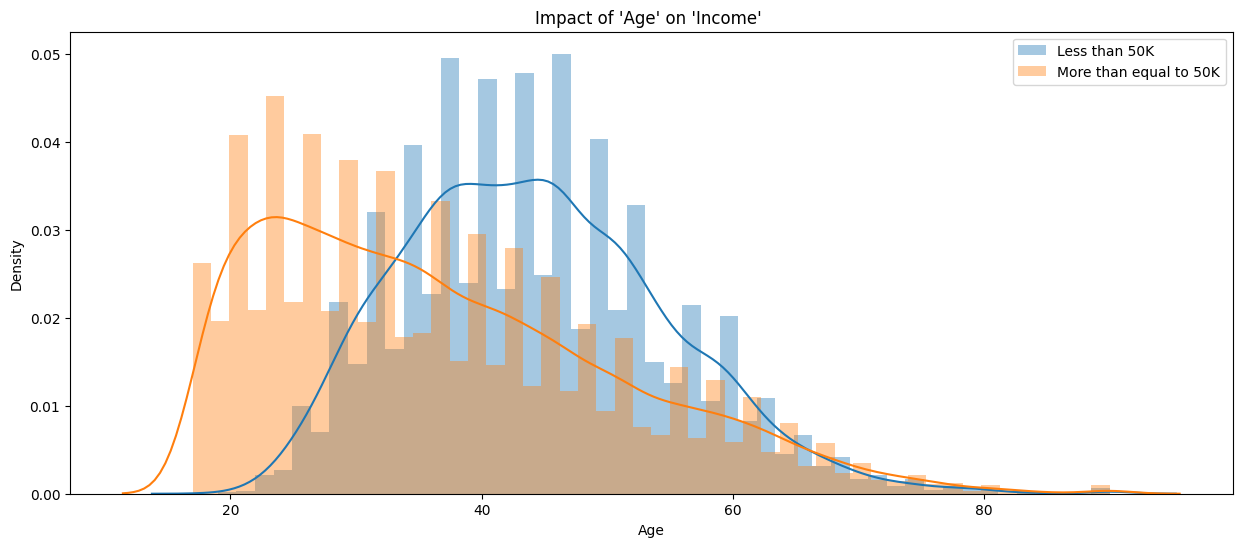

In [14]:
plt.figure(figsize = (15,6))
sns.distplot(df.age[df.income == '>50K'], label = 'Less than 50K')
sns.distplot(df.age[df.income == '<=50K'], label = 'More than equal to 50K')
plt.title("Impact of 'Age' on 'Income' ")
plt.xlabel('Age')
plt.legend()
plt.show()

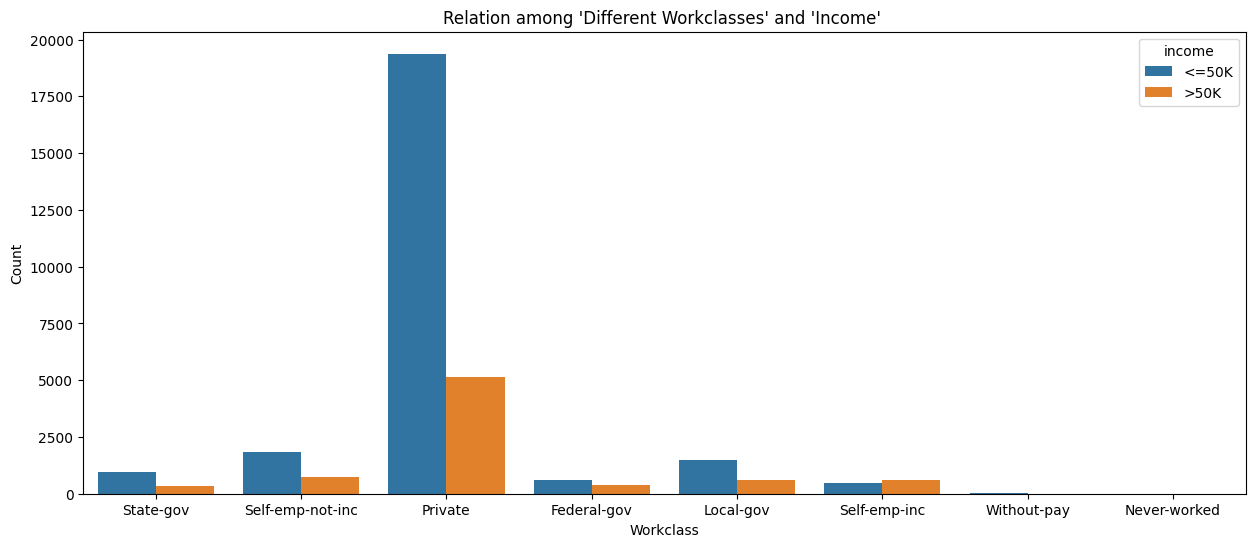

In [15]:
plt.figure(figsize = (15,6))
sns.countplot(x = df.workclass, hue = df.income)
plt.title("Relation among 'Different Workclasses' and 'Income' ")
plt.xlabel('Workclass')
plt.ylabel('Count')
plt.show()

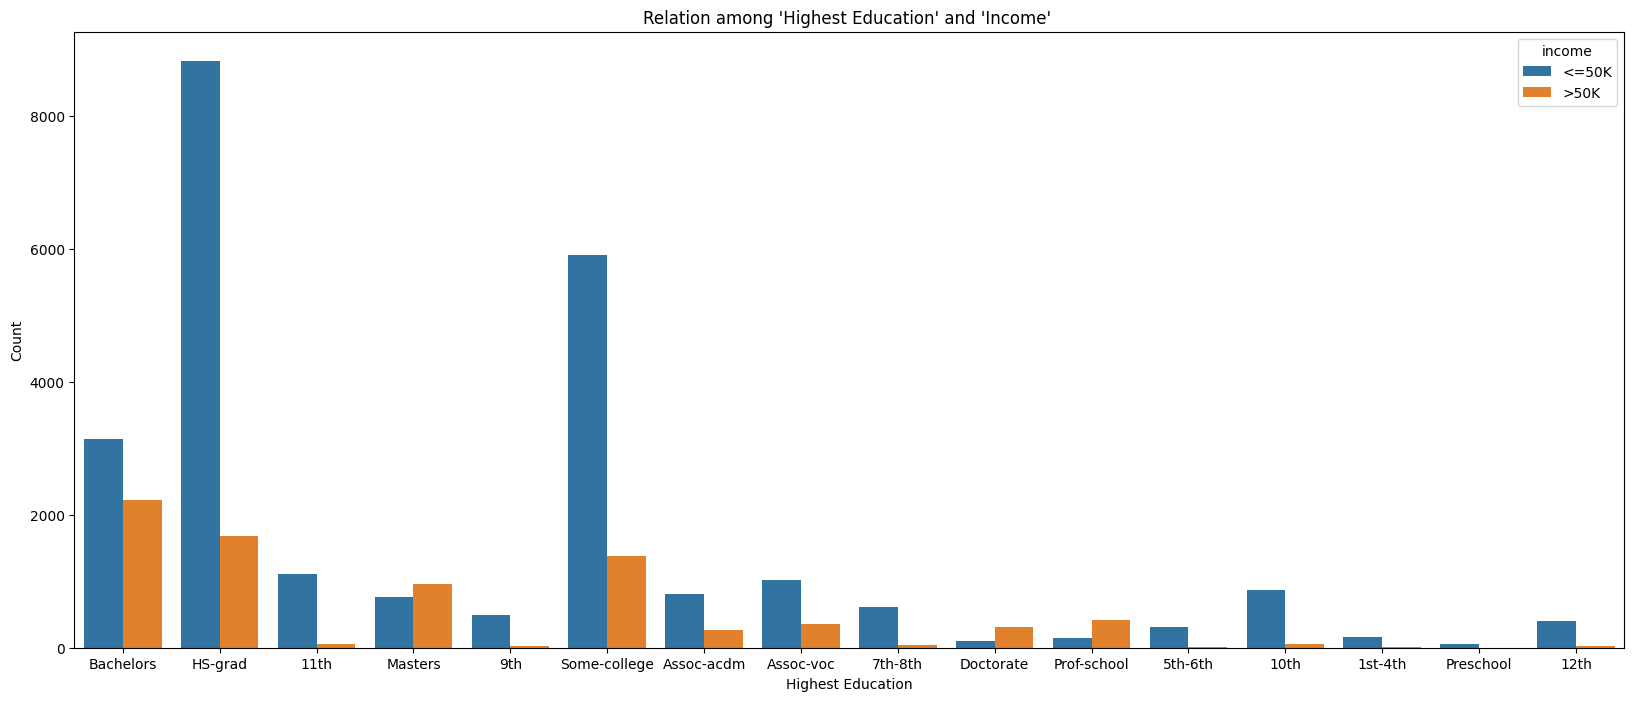

In [16]:
plt.figure(figsize = (20,8))
sns.countplot(x = df.education, hue = df.income)
plt.title("Relation among 'Highest Education' and 'Income' ")
plt.xlabel('Highest Education')
plt.ylabel('Count')
plt.show()

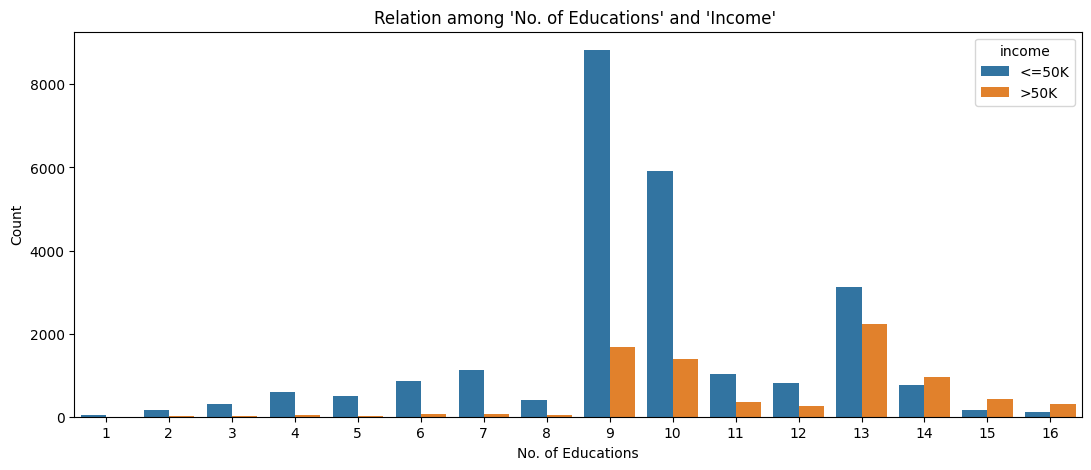

In [17]:
plt.figure(figsize = (13,5))
sns.countplot(x = df['education-num'], hue = df.income)
plt.title("Relation among 'No. of Educations' and 'Income' ")
plt.xlabel('No. of Educations')
plt.ylabel('Count')
plt.show()

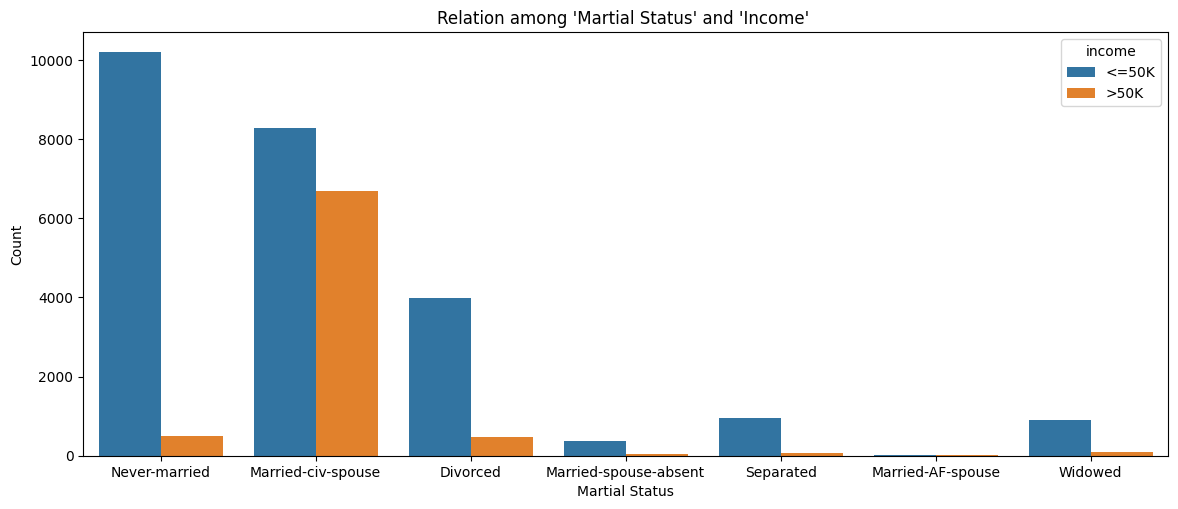

In [18]:
plt.figure(figsize = (14,5.5))
sns.countplot(x = df['martial-status'], hue = df.income)
plt.title("Relation among 'Martial Status' and 'Income' ")
plt.xlabel('Martial Status')
plt.ylabel('Count')
plt.show()

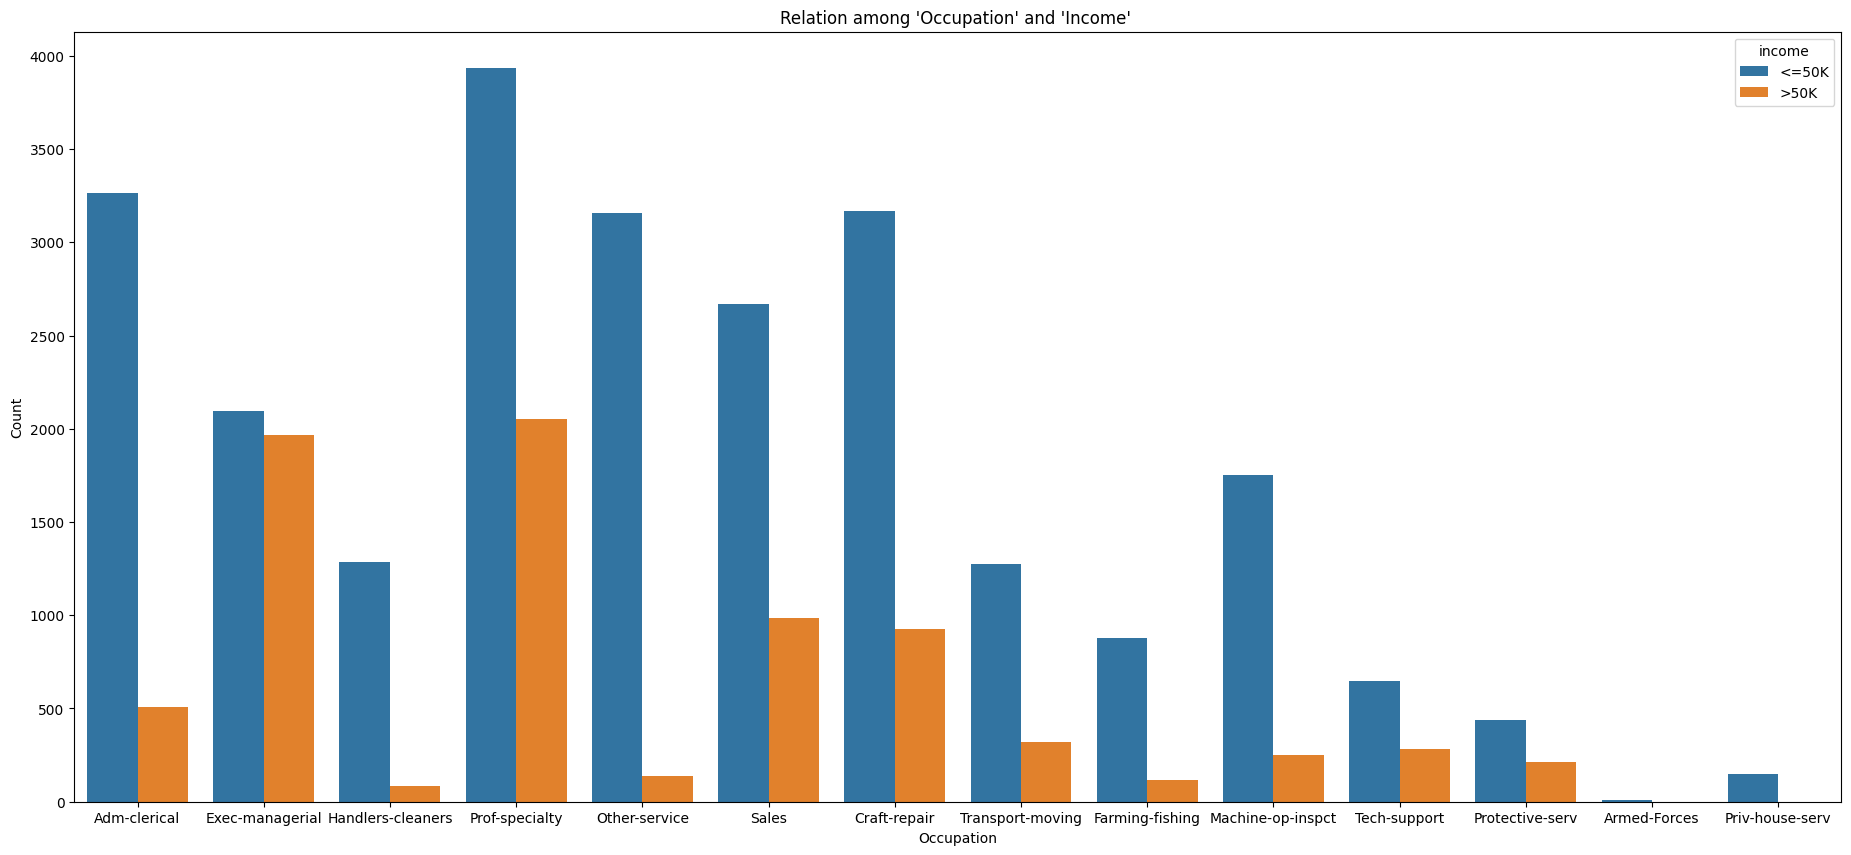

In [19]:
plt.figure(figsize = (22.8,10))
sns.countplot(x = df.occupation, hue = df.income)
plt.title("Relation among 'Occupation' and 'Income' ")
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.show()

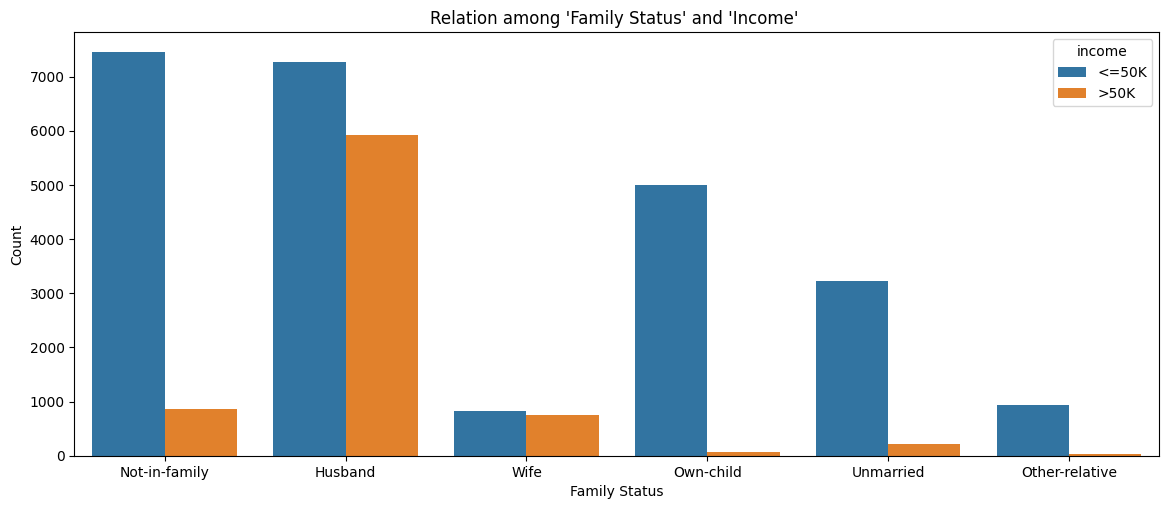

In [20]:
plt.figure(figsize = (14,5.5))
sns.countplot(x = df.relationship, hue = df.income)
plt.title("Relation among 'Family Status' and 'Income' ")
plt.xlabel('Family Status')
plt.ylabel('Count')
plt.show()

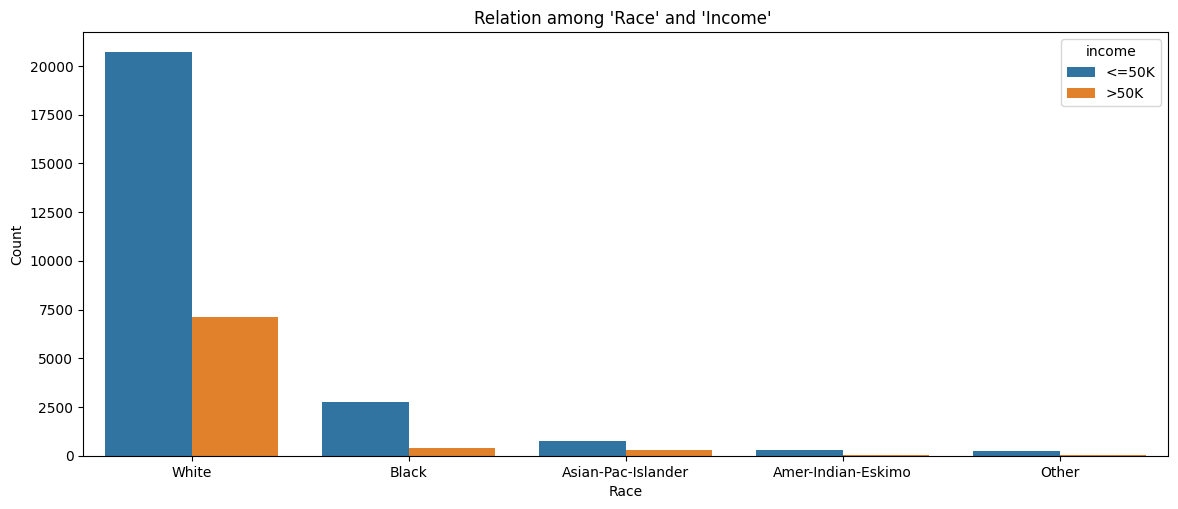

In [21]:
plt.figure(figsize = (14,5.5))
sns.countplot(x = df.race, hue = df.income)
plt.title("Relation among 'Race' and 'Income' ")
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

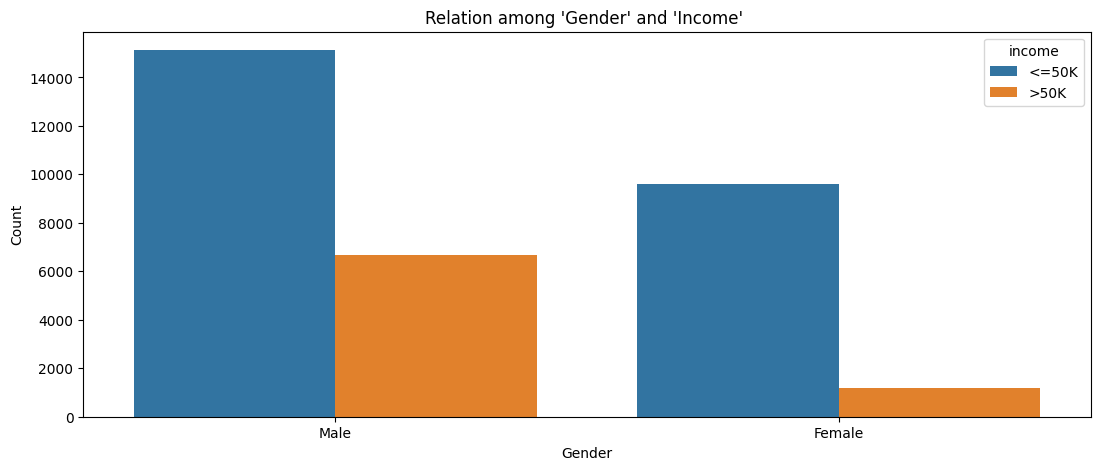

In [22]:
plt.figure(figsize = (13,5))
sns.countplot(x = df.sex, hue = df.income)
plt.title("Relation among 'Gender' and 'Income' ")
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

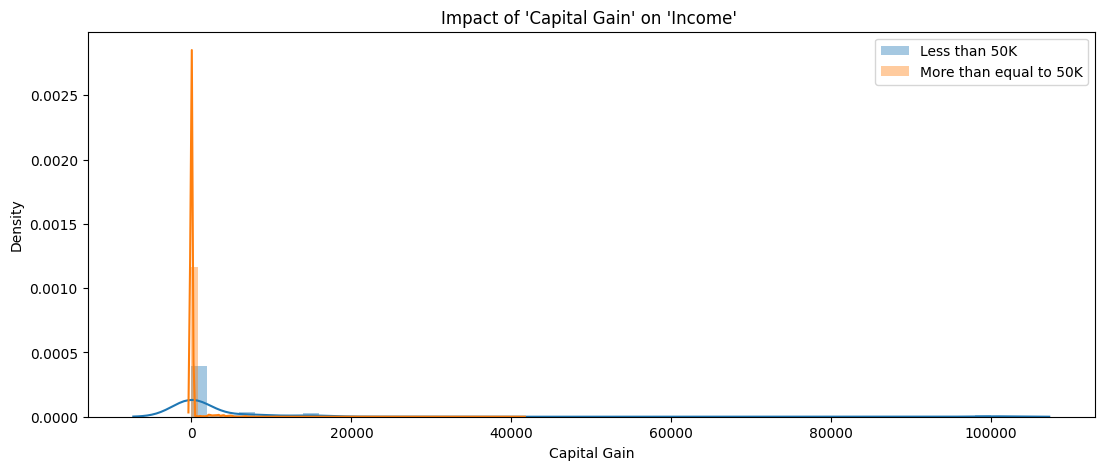

In [23]:
plt.figure(figsize = (13,5))
sns.distplot(df['capital-gain'][df.income == '>50K'], label = 'Less than 50K')
sns.distplot(df['capital-gain'][df.income == '<=50K'], label = 'More than equal to 50K')
plt.title("Impact of 'Capital Gain' on 'Income' ")
plt.xlabel('Capital Gain')
plt.legend()
plt.show()

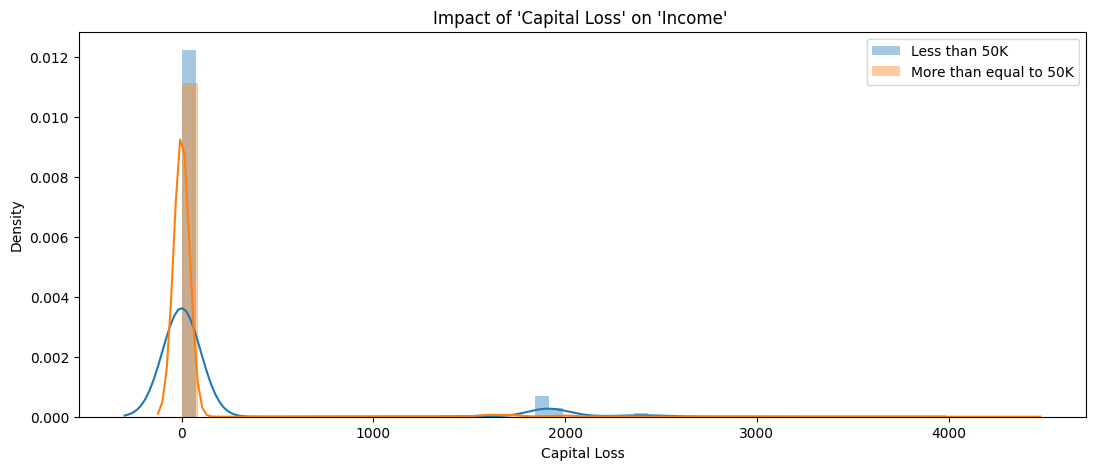

In [24]:
plt.figure(figsize = (13,5))
sns.distplot(df['capital-loss'][df.income == '>50K'], label = 'Less than 50K')
sns.distplot(df['capital-loss'][df.income == '<=50K'], label = 'More than equal to 50K')
plt.title("Impact of 'Capital Loss' on 'Income' ")
plt.xlabel('Capital Loss')
plt.legend()
plt.show()

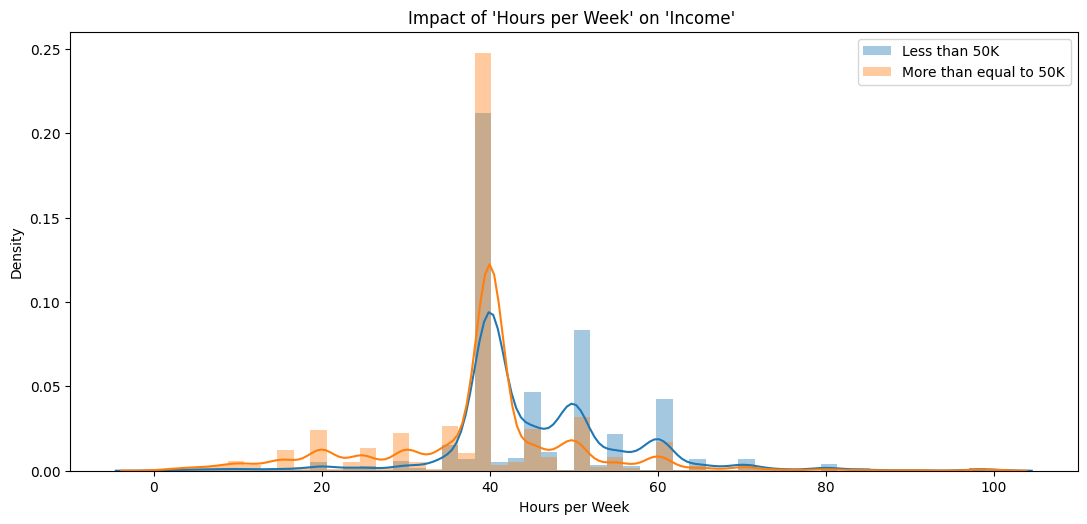

In [25]:
plt.figure(figsize = (13,5.7))
sns.distplot(df['hours-per-week'][df.income == '>50K'], label = 'Less than 50K')
sns.distplot(df['hours-per-week'][df.income == '<=50K'], label = 'More than equal to 50K')
plt.title("Impact of 'Hours per Week' on 'Income' ")
plt.xlabel('Hours per Week')
plt.legend()
plt.show()

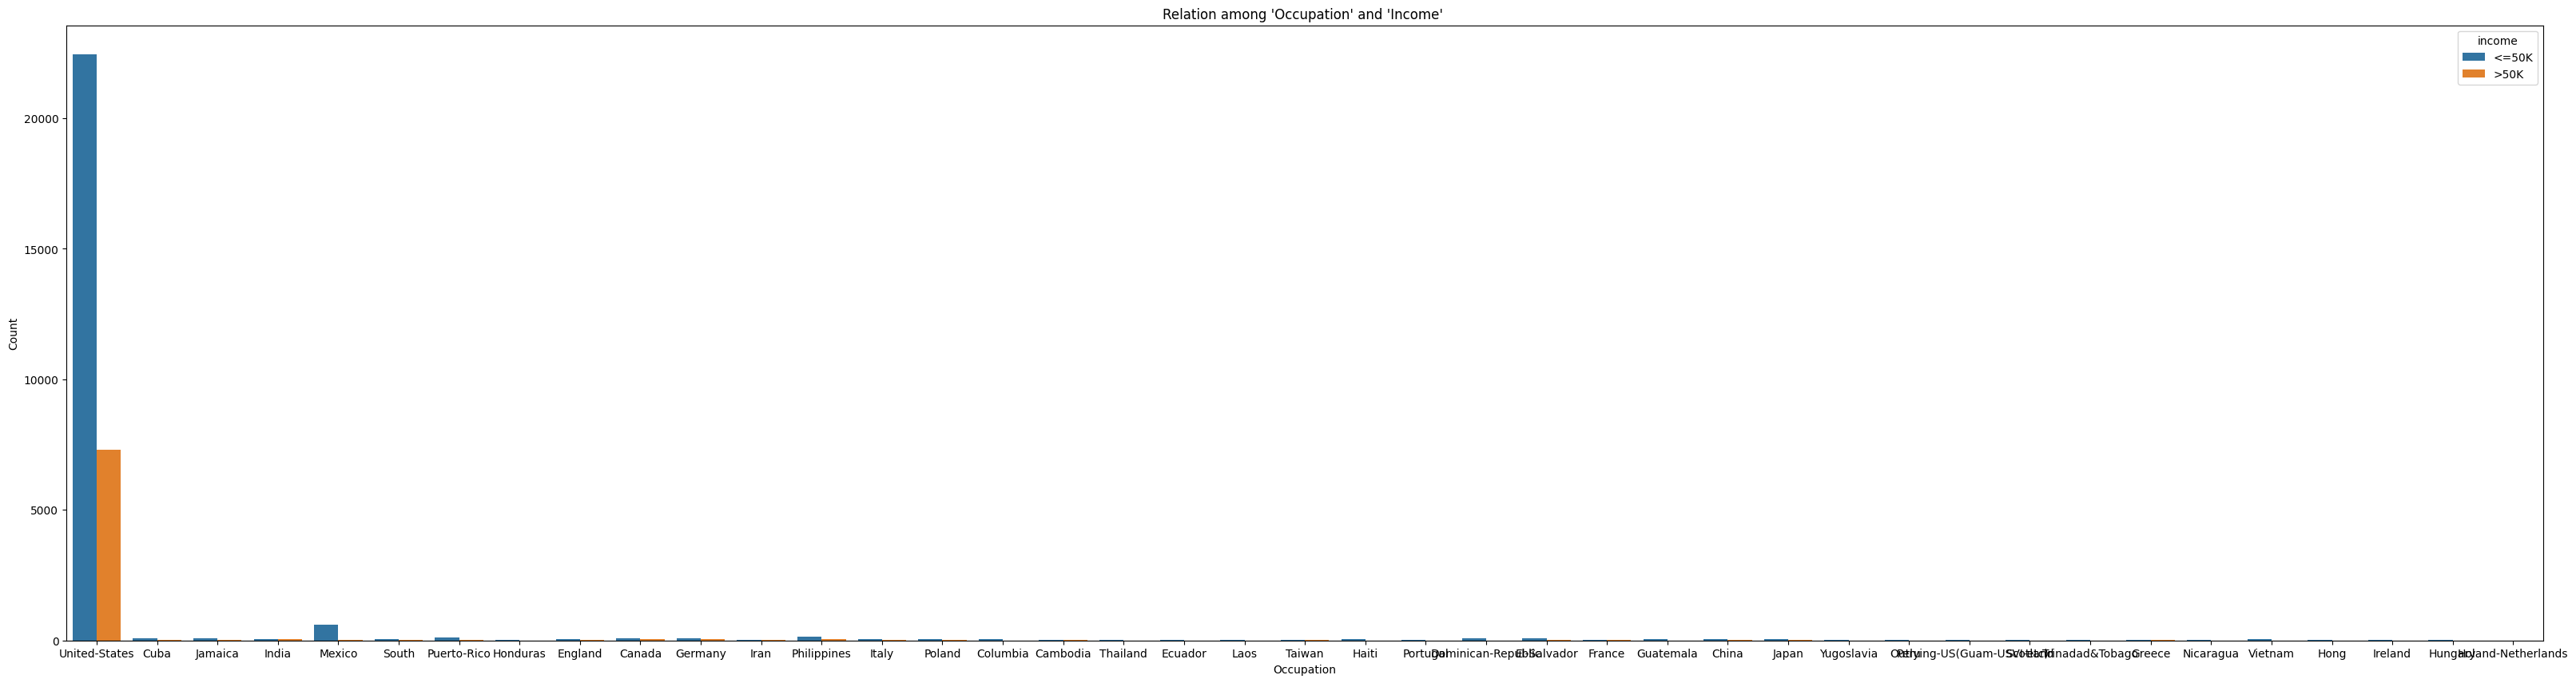

In [26]:
plt.figure(figsize = (40,10))
sns.countplot(x = df['native-country'], hue = df.income)
plt.title("Relation among 'Occupation' and 'Income' ")
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.show()

# Label Encoding

In [27]:
df1 = df
df1

,age,workclass,education,education-num,martial-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [28]:
le1 = LabelEncoder()
df1.workclass = le1.fit_transform(df1.workclass)
print(df1.workclass.unique())
le1.inverse_transform(list(range(7,-1,-1)))

[6 5 3 0 1 4 7 2]


array(['Without-pay', 'State-gov', 'Self-emp-not-inc', 'Self-emp-inc',
       'Private', 'Never-worked', 'Local-gov', 'Federal-gov'],
      dtype=object)

In [29]:
le2 = LabelEncoder()
df1.education = le2.fit_transform(df1.education)
print(df1.education.unique())
le2.inverse_transform(list(range(15,-1,-1)))

[ 9 11  1 12  6 15  7  8  5 10 14  4  0  3 13  2]


array(['Some-college', 'Prof-school', 'Preschool', 'Masters', 'HS-grad',
       'Doctorate', 'Bachelors', 'Assoc-voc', 'Assoc-acdm', '9th',
       '7th-8th', '5th-6th', '1st-4th', '12th', '11th', '10th'],
      dtype=object)

In [30]:
le3 = LabelEncoder()
df1['martial-status'] = le3.fit_transform(df1['martial-status'])
print(df1['martial-status'].unique())
le3.inverse_transform(list(range(6,-1,-1)))

[4 2 0 3 5 1 6]


array(['Widowed', 'Separated', 'Never-married', 'Married-spouse-absent',
       'Married-civ-spouse', 'Married-AF-spouse', 'Divorced'],
      dtype=object)

In [31]:
le4 = LabelEncoder()
df1.occupation = le4.fit_transform(df1.occupation)
print(df1.occupation.unique())
le4.inverse_transform(list(range(13,-1,-1)))

[ 0  3  5  9  7 11  2 13  4  6 12 10  1  8]


array(['Transport-moving', 'Tech-support', 'Sales', 'Protective-serv',
       'Prof-specialty', 'Priv-house-serv', 'Other-service',
       'Machine-op-inspct', 'Handlers-cleaners', 'Farming-fishing',
       'Exec-managerial', 'Craft-repair', 'Armed-Forces', 'Adm-clerical'],
      dtype=object)

In [32]:
le5 = LabelEncoder()
df1.relationship = le5.fit_transform(df1.relationship)
print(df1.relationship.unique())
le5.inverse_transform(list(range(5,-1,-1)))

[1 0 5 3 4 2]


array(['Wife', 'Unmarried', 'Own-child', 'Other-relative',
       'Not-in-family', 'Husband'], dtype=object)

In [33]:
le6 = LabelEncoder()
df1.race = le6.fit_transform(df1.race)
print(df1.race.unique())
le6.inverse_transform(list(range(4,-1,-1)))

[4 2 1 0 3]


array(['White', 'Other', 'Black', 'Asian-Pac-Islander',
       'Amer-Indian-Eskimo'], dtype=object)

In [34]:
le7 = LabelEncoder()
df1.sex = le7.fit_transform(df1.sex)
print(df1.sex.unique())
le7.inverse_transform(list(range(1,-1,-1)))

[1 0]


array(['Male', 'Female'], dtype=object)

In [35]:
le8 = LabelEncoder()
df1.income = le8.fit_transform(df1.income)
print(df1.income.unique())
le8.inverse_transform(list(range(1,-1,-1)))

[0 1]


array(['>50K', '<=50K'], dtype=object)

In [36]:
le9 = LabelEncoder()
df1['native-country'] = le9.fit_transform(df1['native-country'])
print(df1['native-country'].unique())
le9.inverse_transform(list(range(40,-1,-1)))

[38  4 22 18 25 34 32 15  8  1 10 19 29 21 30  3  0 36  6 24 35 13 31  5
  7  9 12  2 23 40 28 27 33 37 11 26 39 16 20 17 14]


array(['Yugoslavia', 'Vietnam', 'United-States', 'Trinadad&Tobago',
       'Thailand', 'Taiwan', 'South', 'Scotland', 'Puerto-Rico',
       'Portugal', 'Poland', 'Philippines', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Nicaragua', 'Mexico', 'Laos',
       'Japan', 'Jamaica', 'Italy', 'Ireland', 'Iran', 'India', 'Hungary',
       'Hong', 'Honduras', 'Holand-Netherlands', 'Haiti', 'Guatemala',
       'Greece', 'Germany', 'France', 'England', 'El-Salvador', 'Ecuador',
       'Dominican-Republic', 'Cuba', 'Columbia', 'China', 'Canada',
       'Cambodia'], dtype=object)

# Co-relation Heatmap

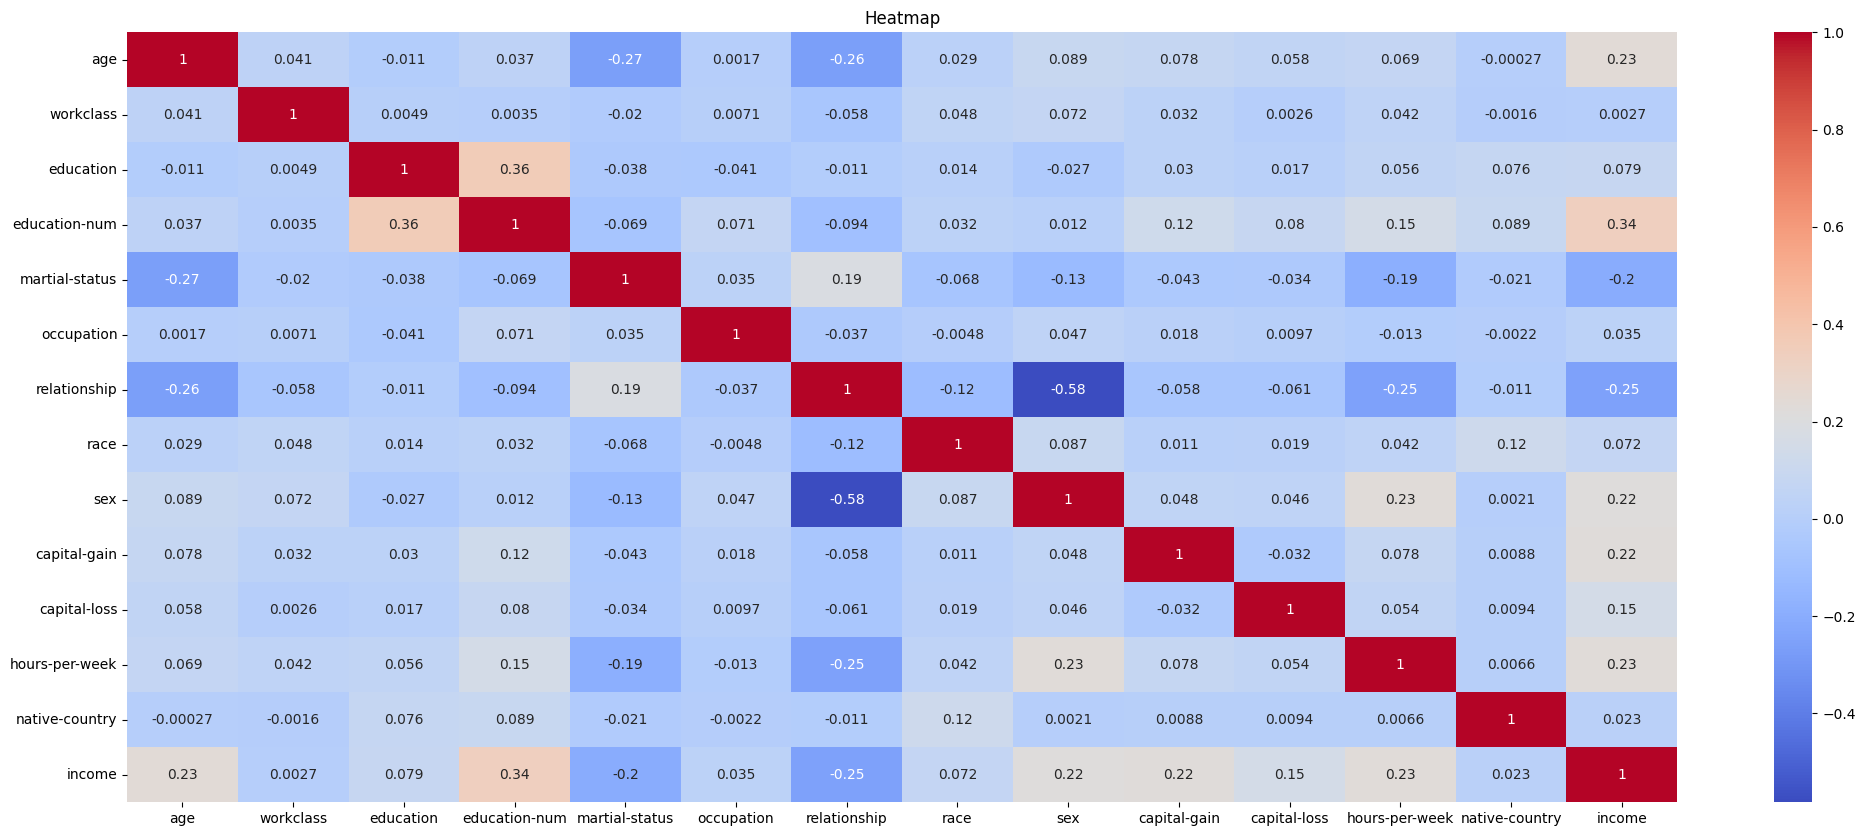

In [37]:
plt.figure(figsize = (25,10))
sns.heatmap(df1.corr(), annot = True, cmap = 'coolwarm')
plt.title('Heatmap')
plt.yticks(rotation = 0)
plt.show()

# Input & Output Creation

In [38]:
ip = df1.drop(['income'], axis = 1)
ip

,age,workclass,education,education-num,martial-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,6,9,13,4,0,1,4,1,2174,0,40,38
1,50,5,9,13,2,3,0,4,1,0,0,13,38
2,38,3,11,9,0,5,1,4,1,0,0,40,38
3,53,3,1,7,2,5,0,2,1,0,0,40,38
4,28,3,9,13,2,9,5,2,0,0,0,40,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,3,7,12,2,12,5,4,0,0,0,38,38
32557,40,3,11,9,2,6,0,4,1,0,0,40,38
32558,58,3,11,9,6,0,4,4,0,0,0,40,38
32559,22,3,11,9,4,0,3,4,1,0,0,20,38


In [39]:
op = df1['income']
op

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    1
32558    0
32559    0
32560    1
Name: income, Length: 32561, dtype: int32

# One Hot Encoding

In [40]:
ct = ColumnTransformer([('workclass', OneHotEncoder(), [1]),
                        ('education', OneHotEncoder(), [2]),
                        ('martial-status', OneHotEncoder(), [4]),
                        ('occupation', OneHotEncoder(), [5]),
                        ('relationship', OneHotEncoder(), [6]),
                        ('race', OneHotEncoder(), [7]),
                        ('sex', OneHotEncoder(), [8]),
                        ('native-country', OneHotEncoder(), [12])], remainder = 'passthrough')
ct

ColumnTransformer(remainder='passthrough',
                  transformers=[('workclass', OneHotEncoder(), [1]),
                                ('education', OneHotEncoder(), [2]),
                                ('martial-status', OneHotEncoder(), [4]),
                                ('occupation', OneHotEncoder(), [5]),
                                ('relationship', OneHotEncoder(), [6]),
                                ('race', OneHotEncoder(), [7]),
                                ('sex', OneHotEncoder(), [8]),
                                ('native-country', OneHotEncoder(), [12])])

In [41]:
ip = ct.fit_transform(ip)
if hasattr(ip, "toarray"): ip = ip.toarray()
print("Shape:", ip.shape)
ip = np.array(ip, dtype=str)
#else: ip = np.array(ip.flatten(), dtype=str)
ip

Shape: (32561, 104)


array([['0.0', '0.0', '0.0', ..., '2174.0', '0.0', '40.0'],
       ['0.0', '0.0', '0.0', ..., '0.0', '0.0', '13.0'],
       ['0.0', '0.0', '0.0', ..., '0.0', '0.0', '40.0'],
       ...,
       ['0.0', '0.0', '0.0', ..., '0.0', '0.0', '40.0'],
       ['0.0', '0.0', '0.0', ..., '0.0', '0.0', '20.0'],
       ['0.0', '0.0', '0.0', ..., '15024.0', '0.0', '40.0']], dtype='<U32')

# Train Test Split

In [42]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.8)
df.shape, x_train.shape, x_test.shape

((32561, 14), (26048, 104), (6513, 104))

# Standard Scaler

In [43]:
sc = StandardScaler()
sc

StandardScaler()

In [44]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

# Logistic Regression

In [45]:
log = LogisticRegression()
log.fit(x_train, y_train)

LogisticRegression()

In [46]:
ycap = log.predict(x_test)
ycap

array([0, 0, 0, ..., 0, 0, 0])

In [47]:
cm = confusion_matrix(ycap, y_test)
pd.DataFrame(cm)

,0,1
0,4612,598
1,356,947


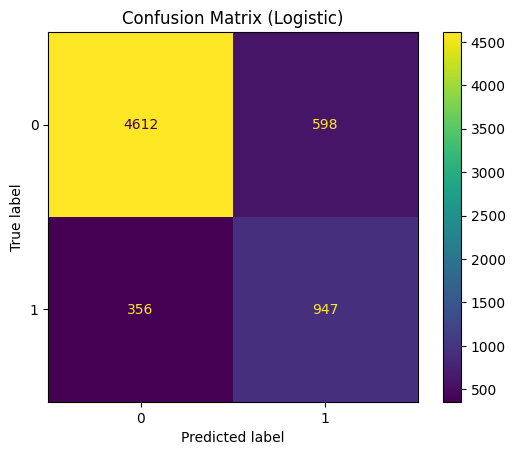

In [48]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.title('Confusion Matrix (Logistic)')
plt.show()

In [49]:
acs = accuracy_score(ycap, y_test)
rcs = recall_score(ycap, y_test)
prs = precision_score(ycap, y_test)
f1s = f1_score(ycap, y_test)
acs, rcs, prs, f1s

(0.8535237217871948,
 0.7267843438219493,
 0.6129449838187703,
 0.6650280898876405)

# Gaussian Naive Bayes

In [50]:
gb = GaussianNB()
gb.fit(x_train, y_train)

GaussianNB()

In [51]:
ycap1 = gb.predict(x_test)
ycap1

array([0, 0, 0, ..., 0, 0, 0])

In [52]:
acs1 = accuracy_score(ycap1, y_test)
rcs1 = recall_score(ycap1, y_test)
prs1 = precision_score(ycap1, y_test)
f1s1 = f1_score(ycap1, y_test)
acs1, rcs1, prs1, f1s1

(0.7627821280515892, 0.0, 0.0, 0.0)

In [53]:
cm1 = confusion_matrix(ycap1, y_test)
pd.DataFrame(cm1)

,0,1
0,4968,1545
1,0,0


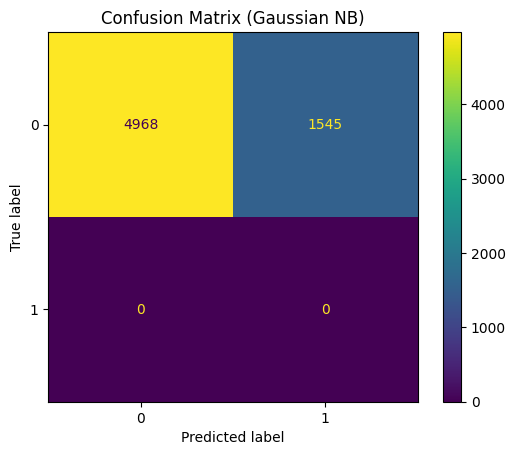

In [54]:
cmd1 = ConfusionMatrixDisplay(cm1)
cmd1.plot()
plt.title('Confusion Matrix (Gaussian NB)')
plt.show()

# K Nearest Neighbors

In [55]:
knn = KNeighborsClassifier(n_neighbors = 15)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=15)

In [56]:
ycap2 = knn.predict(x_test)
ycap2

array([0, 0, 1, ..., 0, 0, 0])

In [57]:
acs2 = accuracy_score(ycap2, y_test)
rcs2 = recall_score(ycap2, y_test)
prs2 = precision_score(ycap2, y_test)
f1s2 = f1_score(ycap2, y_test)
acs2, rcs2, prs2, f1s2

(0.8347919545524336,
 0.6772486772486772,
 0.5799352750809061,
 0.6248256624825662)

In [58]:
cm2 = confusion_matrix(ycap2, y_test)
pd.DataFrame(cm2)

,0,1
0,4541,649
1,427,896


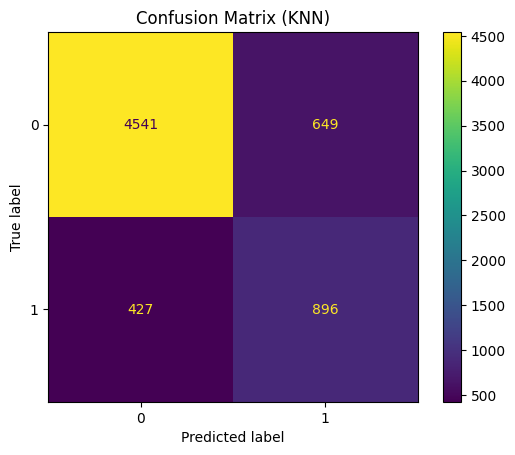

In [59]:
cmd2 = ConfusionMatrixDisplay(cm2)
cmd2.plot()
plt.title('Confusion Matrix (KNN)')
plt.show()

# Support Vector Machine

In [60]:
sv = svm.SVC(kernel = 'rbf', C = 100, gamma = 0.05)
sv.fit(x_train, y_train)

SVC(C=100, gamma=0.05)

In [61]:
ycap3 = sv.predict(x_test)
ycap3

array([0, 0, 1, ..., 0, 0, 0])

In [62]:
acs3 = accuracy_score(ycap3, y_test)
rcs3 = recall_score(ycap3, y_test)
prs3 = precision_score(ycap3, y_test)
f1s3 = f1_score(ycap3, y_test)
acs3, rcs3, prs3, f1s3

(0.8255796100107478,
 0.6493791088385683,
 0.5754045307443366,
 0.6101578586135896)

In [63]:
cm3 = confusion_matrix(ycap3, y_test)
pd.DataFrame(cm3)

,0,1
0,4488,656
1,480,889


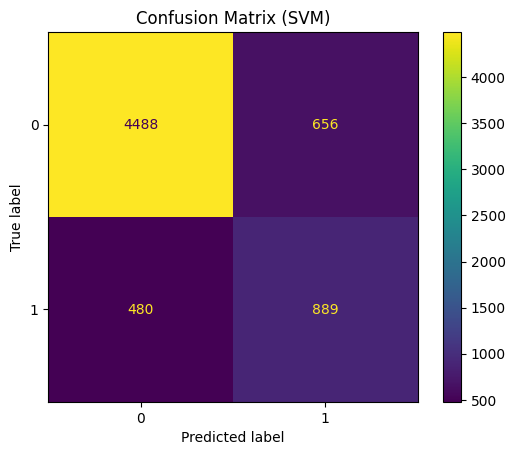

In [64]:
cmd3 = ConfusionMatrixDisplay(cm3)
cmd3.plot()
plt.title('Confusion Matrix (SVM)')
plt.show()

# Prediction

In [65]:
pdf = pd.DataFrame({'y':list(y_test),
                    'Prediction (Logistic)':ycap,
                    'Prediction (Gaussian NB)':ycap1,
                    'Prediction (KNN)':ycap2,
                    'Prediction (SVM)':ycap3})
pdf

,y,Prediction (Logistic),Prediction (Gaussian NB),Prediction (KNN),Prediction (SVM)
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,1,1
3,0,0,0,0,0
4,0,0,0,0,1
...,...,...,...,...,...
6508,0,0,0,0,0
6509,0,0,0,0,1
6510,1,0,0,0,0
6511,0,0,0,0,0


# Metrics

In [66]:
print("Accuracy Score (Logistic):\t", acs)
print("Accuracy Score (Gaussian NB):\t", acs1)
print("Accuracy Score (KNN):\t\t", acs2)
print("Accuracy Score (SVM):\t\t", acs3)

print("\nRecall Score (Logistic):\t", rcs)
print("Recall Score (Gaussian NB):\t", rcs1)
print("Recall Score (KNN):\t\t", rcs2)
print("Recall Score (SVM):\t\t", rcs3)

print("\nPrecision Score (Logistic):\t", prs)
print("Precision Score (Gaussian NB):\t", prs1)
print("Precision Score (KNN):\t\t", prs2)
print("Precision Score (SVM):\t\t", prs3)

print("\nF1 Score (Logistic):\t\t", f1s)
print("F1 Score (Gaussian NB):\t\t", f1s1)
print("F1 Score (KNN):\t\t\t", f1s2)
print("F1 Score (SVM):\t\t\t", f1s3)

Accuracy Score (Logistic):	 0.8535237217871948
Accuracy Score (Gaussian NB):	 0.7627821280515892
Accuracy Score (KNN):		 0.8347919545524336
Accuracy Score (SVM):		 0.8255796100107478

Recall Score (Logistic):	 0.7267843438219493
Recall Score (Gaussian NB):	 0.0
Recall Score (KNN):		 0.6772486772486772
Recall Score (SVM):		 0.6493791088385683

Precision Score (Logistic):	 0.6129449838187703
Precision Score (Gaussian NB):	 0.0
Precision Score (KNN):		 0.5799352750809061
Precision Score (SVM):		 0.5754045307443366

F1 Score (Logistic):		 0.6650280898876405
F1 Score (Gaussian NB):		 0.0
F1 Score (KNN):			 0.6248256624825662
F1 Score (SVM):			 0.6101578586135896
